# Exploratory Synthetic Data Analysis

## Health Report for synthetic attacks Dataset

In [2]:
import pandas as pd
from ai_waf_v2.data import WafDataset

#### Inspection of parquet file

In [3]:
df = pd.read_parquet("../data/augmented/synthesis/synthesized_attacks.parquet")
print(f"--- Augmented Dataset ---")
print("Columns:", df.columns.tolist())

print("\n--- Rows ---")
print(f"{len(df)}")

print("\n--- Unique Categories ---")
print(df['attack_class'].unique())

print("\n--- Unique Labels ---")
print(df['label'].unique())

print("\n--- Distribution (Counts) ---")
print(df.groupby(['attack_class', 'label']).size().reset_index(name='count'))

with pd.option_context('display.max_colwidth', None):
    # See 5 random rows to check different attack categories
    result = df.sample(5)
    display(result)

print("\n--- Unique Raw ---")
print(df['raw'].nunique())


--- Augmented Dataset ---
Columns: ['id', 'method', 'path', 'query_string', 'headers', 'body', 'raw', 'label', 'attack_class', 'source', 'split']

--- Rows ---
39506

--- Unique Categories ---
['xxe' 'header_injection' 'ssti' 'ssrf' 'xss' 'lfi' 'cmdi'
 'path_traversal']

--- Unique Labels ---
[1]

--- Distribution (Counts) ---
       attack_class  label  count
0              cmdi      1   4911
1  header_injection      1   5000
2               lfi      1   5000
3    path_traversal      1   5000
4              ssrf      1   5000
5              ssti      1   5000
6               xss      1   4595
7               xxe      1   5000


,id,method,path,query_string,headers,body,raw,label,attack_class,source,split
2630,20376daa-ab65-434b-9d74-6dbc039524dd,POST,/api/v1/xml,,"{""Host"": ""stub.invalid"", ""User-Agent"": ""stub""}",```xml\n<!DOCTYPE%0droot%09[%09<!ENTITY%0d%\txxe%0dSYSTEM 'http://internal-ip:8080/sensitive-data.txt'\n>\n]>\n<root><%xxe;></root>,POST /api/v1/xml HTTP/1.1\r\nHost: stub.invalid\r\nUser-Agent: stub\r\n\r\n```xml\n<!DOCTYPE%0droot%09[%09<!ENTITY%0d%\txxe%0dSYSTEM 'http://internal-ip:8080/sensitive-data.txt'\n>\n]>\n<root><%xxe;></root>,1,xxe,aug_synthesis_xxe,
11961,e9897b49-c228-4ded-a992-4db2df728c40,GET,/api/v1/render,template={{7*7}}}},"{""Host"": ""stub.invalid"", ""User-Agent"": ""stub""}",,GET /api/v1/render?template={{7*7}}}} HTTP/1.1\r\nHost: stub.invalid\r\nUser-Agent: stub\r\n,1,ssti,aug_synthesis_ssti,
36544,e8ae7942-1cf6-44e9-9311-8b5c3ca635ff,GET,/download,file=..%2f../../../proc/self/environ%20,"{""Host"": ""stub.invalid"", ""User-Agent"": ""stub""}",,GET /download?file=..%2f../../../proc/self/environ%20 HTTP/1.1\r\nHost: stub.invalid\r\nUser-Agent: stub\r\n,1,path_traversal,aug_synthesis_path_traversal,
4825,4d2b9833-ecc4-4d00-82c7-fb187923c839,POST,/api/v1/xml,,"{""Host"": ""stub.invalid"", ""User-Agent"": ""stub""}",%253C%2521DOCTYPE%2520test%2520SYSTEM%2520%2527xentity%253A%2528http%253A%252F%252Flocalhost%252Fconf%252Fpasswd%2529%2527%253E,POST /api/v1/xml HTTP/1.1\r\nHost: stub.invalid\r\nUser-Agent: stub\r\n\r\n%253C%2521DOCTYPE%2520test%2520SYSTEM%2520%2527xentity%253A%2528http%253A%252F%252Flocalhost%252Fconf%252Fpasswd%2529%2527%253E,1,xxe,aug_synthesis_xxe,
3045,da8dd32f-d0d9-4edb-a737-5cf2cbac16d4,POST,/api/v1/xml,,"{""Host"": ""stub.invalid"", ""User-Agent"": ""stub""}","""```&#120;&#109;&#108;\&#110;<!&#68;&#79;&#67;&#84;&#89;&#80;&#69;/**/&#114;&#111;&#111;&#116;/**/[","POST /api/v1/xml HTTP/1.1\r\nHost: stub.invalid\r\nUser-Agent: stub\r\n\r\n""```&#120;&#109;&#108;\&#110;<!&#68;&#79;&#67;&#84;&#89;&#80;&#69;/**/&#114;&#111;&#111;&#116;/**/[",1,xxe,aug_synthesis_xxe,



--- Unique Raw ---
34219


#### Check Label and Category Ratios

This identifies if your dataset is imbalanced. In WAF research, an **extreme imbalance** (e.g., 99% benign) requires specific handling during training.

In [16]:

# 1. Binary Label Distribution (0 vs 1)
print("--- Binary Label Counts ---")
print(df['label'].value_counts())
print("\n--- Binary Label Ratios ---")
print(df['label'].value_counts(normalize=True))

# 2. Specific Attack Category Distribution
print("\n--- Attack Category Counts ---")
print(df['category'].value_counts())
print("\n--- Attack Category Ratios ---")
print(df['category'].value_counts(normalize=True))


--- Binary Label Counts ---
label
000 - Normal                              5796
310 - Scanning for Vulnerable Software    2382
126 - Path Traversal                      1806
272 - Protocol Manipulation                 10
66 - SQL Injection                           5
242 - Code Injection                         1
Name: count, dtype: int64

--- Binary Label Ratios ---
label
000 - Normal                              0.5796
310 - Scanning for Vulnerable Software    0.2382
126 - Path Traversal                      0.1806
272 - Protocol Manipulation               0.0010
66 - SQL Injection                        0.0005
242 - Code Injection                      0.0001
Name: proportion, dtype: float64

--- Attack Category Counts ---
category
Normal                              5796
Scanning for Vulnerable Software    2382
Manipulation                        1816
Injection                              6
Name: count, dtype: int64

--- Attack Category Ratios ---
category
Normal                  

#### Cross-Tabulate Label vs. Category

It is a good practice to verify that the label (0 or 1) correctly aligns with the category. This ensures that all categories labeled as "Normal" are actually 0.

In [17]:
# Create a cross-tabulation table
ctab = pd.crosstab(df['category'], df['label'])
print("--- Label Alignment Check ---")
print(ctab)

--- Label Alignment Check ---
label                             000 - Normal  126 - Path Traversal  \
category                                                               
Injection                                    0                     0   
Manipulation                                 0                  1806   
Normal                                    5796                     0   
Scanning for Vulnerable Software             0                     0   

label                             242 - Code Injection  \
category                                                 
Injection                                            1   
Manipulation                                         0   
Normal                                               0   
Scanning for Vulnerable Software                     0   

label                             272 - Protocol Manipulation  \
category                                                        
Injection                                                 

#### Visualizing with a Bar Chart

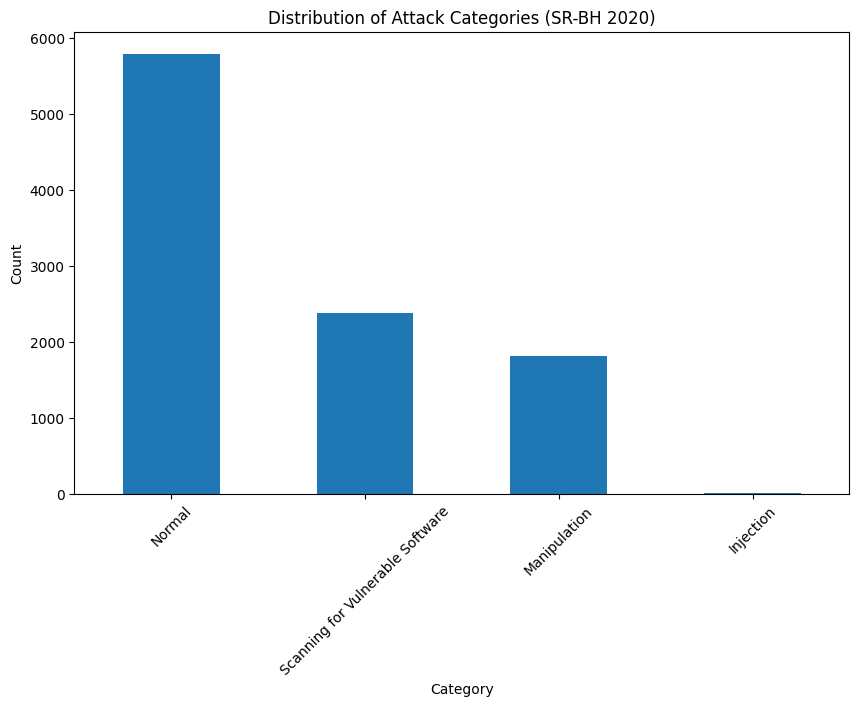

In [18]:
import matplotlib.pyplot as plt

# Plotting the categories
plt.figure(figsize=(10, 6))
df['category'].value_counts().plot(kind='bar')
plt.title('Distribution of Attack Categories (SR-BH 2020)')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

#### Payload Length Analysis

Since we are using DeBERTa-v3, the length of the text field matters. If payloads are extremely long, they will be truncated, potentially losing the malicious part of the string.

In [19]:
# Add a length column for analysis
df['payload_len'] = df['text'].str.len()

print("--- Payload Length Statistics ---")
print(df.groupby('category')['payload_len'].describe())

# Check for empty payloads
print(f"\nEmpty payloads: {df['text'].isna().sum()}")

--- Payload Length Statistics ---
                                   count        mean        std    min    25%  \
category                                                                        
Injection                            6.0  352.666667  32.922130  317.0  326.0   
Manipulation                      1816.0  356.104626  73.016841  193.0  306.0   
Normal                            5796.0  318.537440  75.861232  187.0  269.0   
Scanning for Vulnerable Software  2382.0  209.849706  11.181151  196.0  202.0   

                                    50%     75%    max  
category                                                
Injection                         354.0  367.00  403.0  
Manipulation                      360.0  377.25  623.0  
Normal                            294.0  346.00  723.0  
Scanning for Vulnerable Software  206.0  216.00  284.0  

Empty payloads: 0
